# Student Performance & Study Habits

Predicting a student's final letter grade (A-F) from study habits and background info.
Multi-class classification, 1000 rows.

| Column | Type | Notes |
|--------|------|-------|
| student_id | id | dropped |
| gender | categorical | Male / Female |
| study_time_hours | numeric | hours studied per day |
| attendance_percent | numeric | class attendance % |
| sleep_hours | numeric | avg sleep per night |
| parental_education | categorical, ~10% missing | High School / Bachelors / Masters / PhD |
| internet_access | categorical | Yes / No |
| extracurricular_activities | categorical | Yes / No |
| part_time_job | categorical | Yes / No |
| previous_grade | numeric | prior grade score |
| final_exam_score | numeric | not used as a feature, see below |
| final_grade | A-F | target |

`final_grade` is just a bucketed version of `final_exam_score` (90+ = A, etc.), so I dropped the
raw score as a feature. Otherwise the model would basically be relearning the grade cutoffs
instead of predicting anything from the actual study/behaviour columns.

Pipeline:
1. Load + explore the data
2. EDA - class balance, distributions, skew, correlations
3. Feature engineering
4. Preprocessing - missing values, encoding, scaling
5. Train 9 models (Logistic Regression, Decision Tree, Random Forest, Bagging, AdaBoost,
   Gradient Boosting, SVM, Voting, Stacking)
6. Compare models
7. Hyperparameter tuning with Optuna, one study per model
8. Final evaluation - confusion matrix, classification report, ROC curves


## Step 1: Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("Imports done.")


Imports done.


## Step 2: Load the Dataset

In [3]:
df = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\kaggle\Student Performance & Study Habits\student_performance_dataset.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (1000, 12)


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D
5,6,Female,4.2,78.2,5.7,High School,Yes,No,No,79.8,81.6,B
6,7,Male,1.5,100.0,5.0,High School,Yes,Yes,Yes,58.6,69.6,D
7,8,Male,6.2,86.4,6.0,High School,Yes,Yes,No,78.4,88.0,B
8,9,Male,5.3,81.3,6.7,Bachelors,Yes,No,No,63.8,84.4,B
9,10,Female,2.8,86.8,5.1,Bachelors,Yes,Yes,No,57.7,74.3,C


### Data Types & Missing Values

In [4]:
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Data description:")
print(df.describe())
print()
print("Target distribution (final_grade):")
print(df['final_grade'].value_counts())
print()
print("Target distribution (percentage):")
print(df['final_grade'].value_counts(normalize=True) * 100)


Data types:
student_id                      int64
gender                            str
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education                str
internet_access                   str
extracurricular_activities        str
part_time_job                     str
previous_grade                float64
final_exam_score              float64
final_grade                       str
dtype: object

Missing values:
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

Data description:
        student_id  study_time_hours  attendance_percent  sle

---
## Step 3: EDA

Looking at class balance, feature distributions, skew, and correlations before doing anything
else.


### 3.1 Target Class Distribution
How balanced are the grade buckets? If something like F is really rare, some models will just
ignore it.


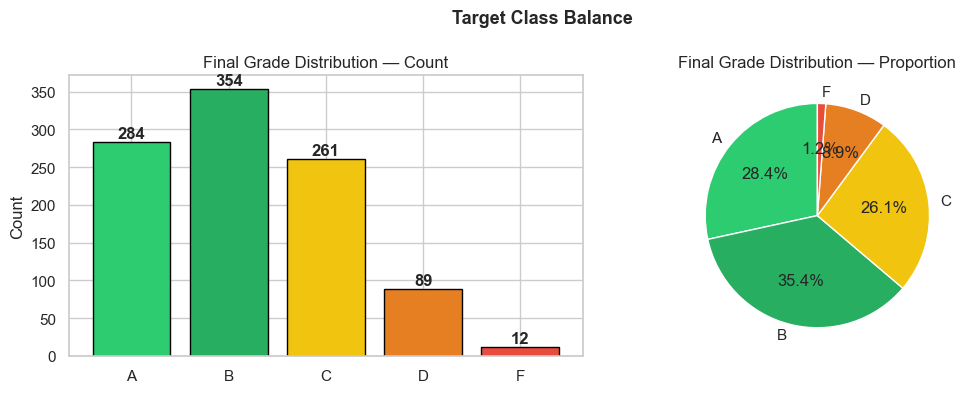

Class counts:
{'A': 284, 'B': 354, 'C': 261, 'D': 89, 'F': 12}

Imbalance ratio (A : F) = 23.67 : 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

grade_order = ['A', 'B', 'C', 'D', 'F']
class_counts = df['final_grade'].value_counts().reindex(grade_order)
colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c']

axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Final Grade Distribution — Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Final Grade Distribution — Proportion')

plt.suptitle('Target Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Class counts:")
print(class_counts.to_dict())
print(f"\nImbalance ratio (A : F) = {class_counts['A'] / class_counts['F']:.2f} : 1")


### 3.2 Feature Distributions
Histograms for the numeric columns, bar counts for the categorical ones.


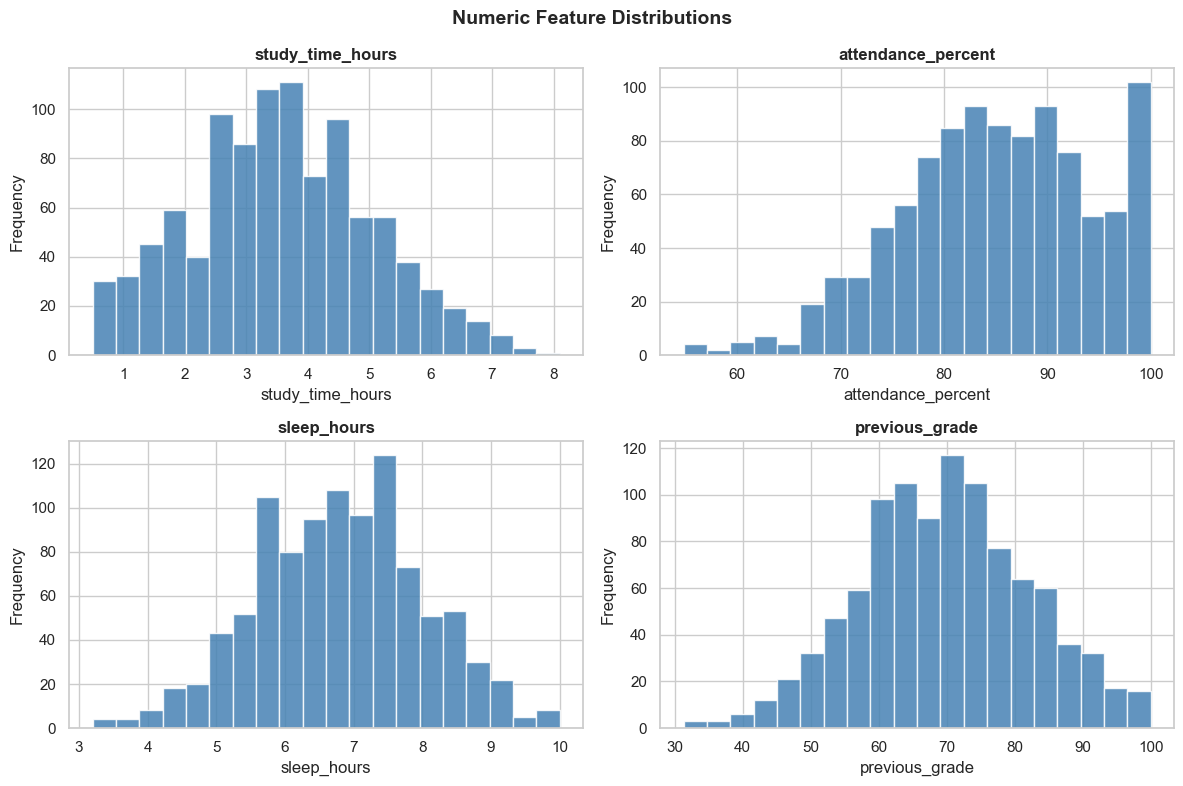

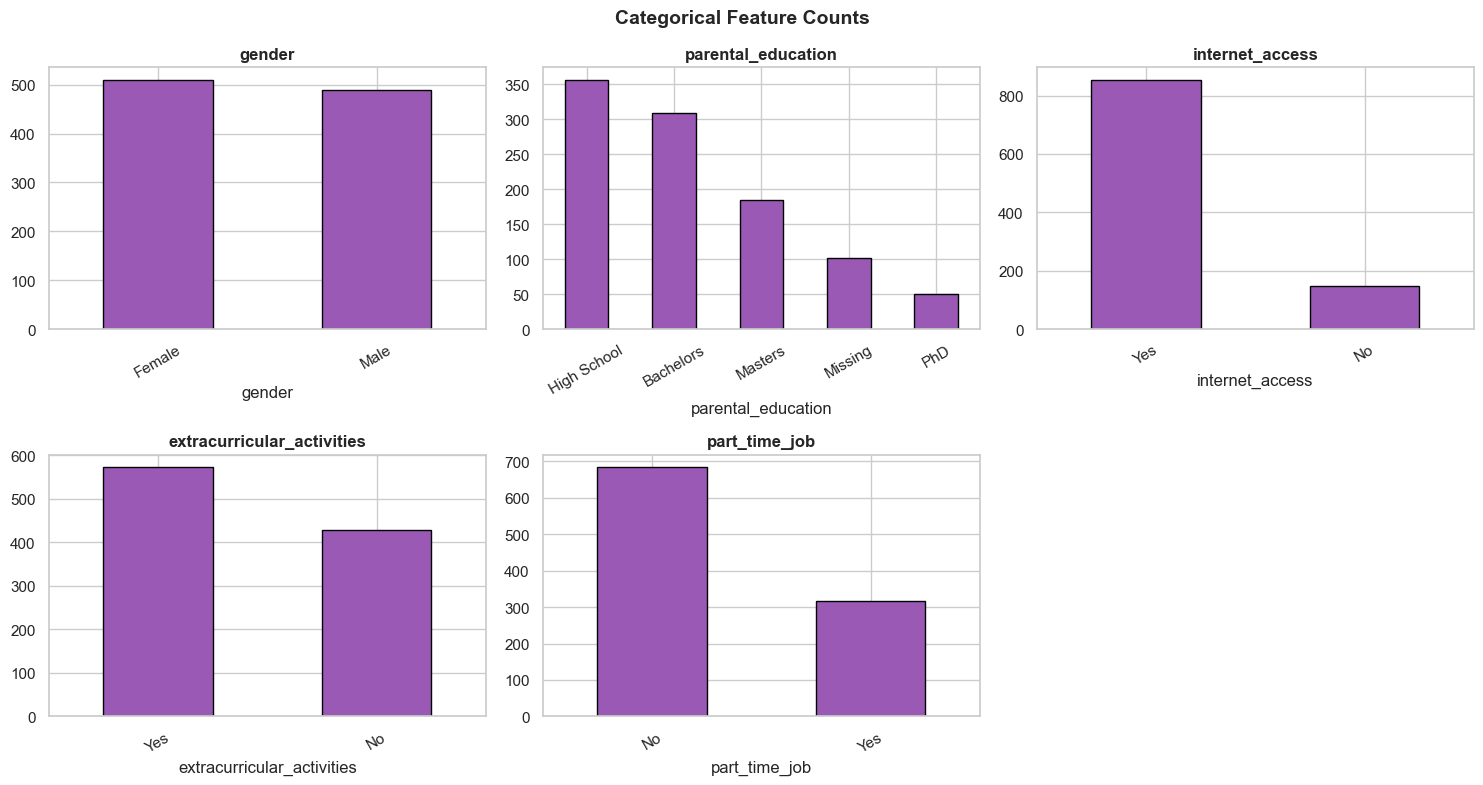

In [6]:
numeric_cols = ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']
categorical_cols = ['gender', 'parental_education', 'internet_access',
                    'extracurricular_activities', 'part_time_job']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    df[col].fillna('Missing').value_counts().plot(kind='bar', ax=axes[i],
                                                    color='#9b59b6', edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Feature Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Feature Distributions by Class
Boxplots of the numeric features grouped by `final_grade` - a feature that separates the grades
well should be obvious here.


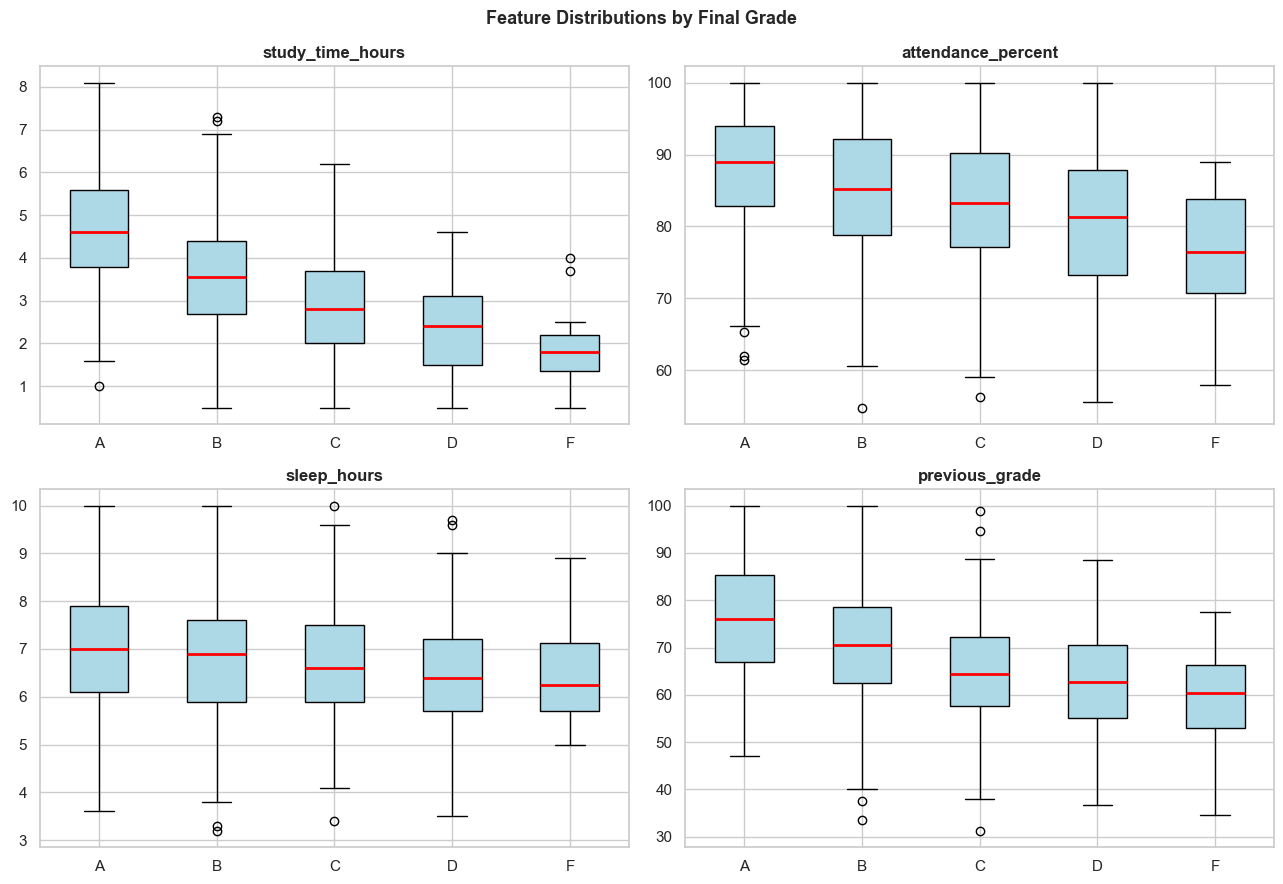

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data_by_grade = [df[df['final_grade'] == g][col] for g in grade_order]
    axes[i].boxplot(data_by_grade, labels=grade_order, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Feature Distributions by Final Grade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 Skew Check
Checking skew on the numeric columns to see if any need a log transform (using |skew| > 0.75 as
the cutoff).


In [8]:
skew_report = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("Skewness of numeric features:")
print(skew_report)

skew_threshold = 0.75
cols_needing_transform = skew_report[abs(skew_report) > skew_threshold].index.tolist()

if cols_needing_transform:
    print(f"\nColumns exceeding |skew| > {skew_threshold}: {cols_needing_transform}")
else:
    print(f"\nNo numeric feature exceeds |skew| > {skew_threshold} — no log/cap transform needed.")


Skewness of numeric features:
attendance_percent   -0.336686
study_time_hours      0.121499
sleep_hours          -0.023095
previous_grade        0.001412
dtype: float64

No numeric feature exceeds |skew| > 0.75 — no log/cap transform needed.


### 3.5 Correlation Heatmap
Quick numeric encoding of the categoricals (EDA only, not used in the actual model) plus an
ordinal version of the target (F < D < C < B < A) so I can look at linear relationships.


Correlation Matrix:
                            gender  study_time_hours  attendance_percent  \
gender                        1.00              0.01                0.01   
study_time_hours              0.01              1.00               -0.04   
attendance_percent            0.01             -0.04                1.00   
sleep_hours                  -0.01              0.01                0.03   
parental_education            0.01              0.05                0.01   
internet_access              -0.02             -0.01               -0.00   
extracurricular_activities   -0.04             -0.00                0.01   
part_time_job                -0.03             -0.02                0.05   
previous_grade               -0.01             -0.04               -0.01   
final_grade_rank              0.01              0.53                0.25   

                            sleep_hours  parental_education  internet_access  \
gender                            -0.01                0.01    

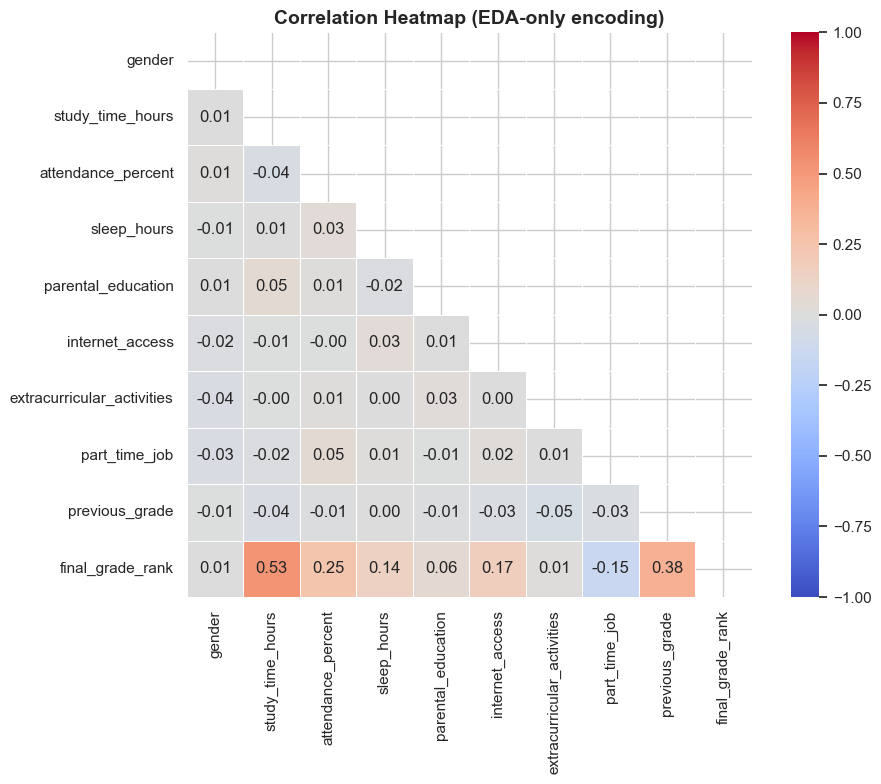

In [9]:
grade_rank = {'F': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}

df_corr = df.drop(columns=['student_id', 'final_exam_score']).copy()
df_corr['final_grade_rank'] = df_corr['final_grade'].map(grade_rank)
df_corr = df_corr.drop(columns='final_grade')

for col in ['gender', 'internet_access', 'extracurricular_activities', 'part_time_job']:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

df_corr['parental_education'] = df_corr['parental_education'].map(
    {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
)

corr = df_corr.corr()
print("Correlation Matrix:")
print(corr.round(2))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (EDA-only encoding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.6 Feature Correlation with Target
Same idea as above, sorted by strength so the most/least predictive features are obvious.


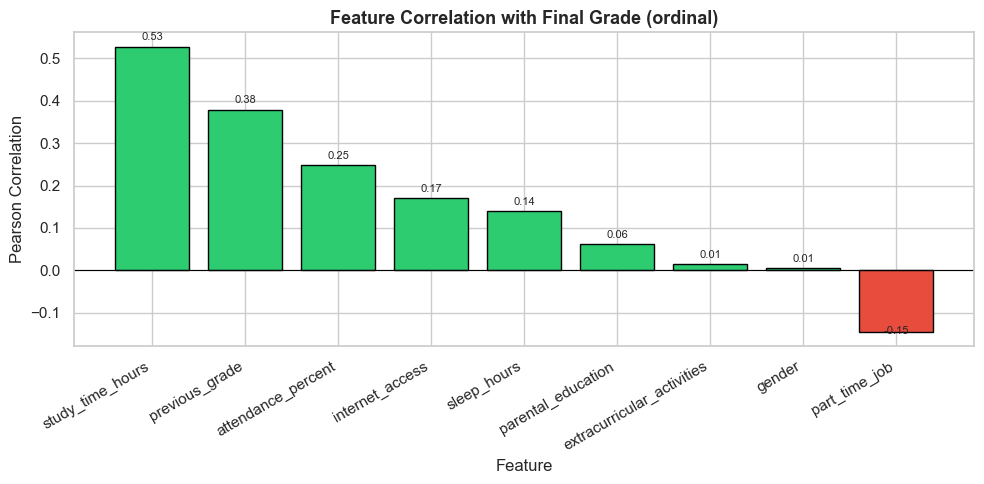

Top positively correlated features:
study_time_hours      0.528008
previous_grade        0.379099
attendance_percent    0.248213
internet_access       0.169760
sleep_hours           0.139010
Name: final_grade_rank, dtype: float64

Top negatively correlated features:
sleep_hours                   0.139010
parental_education            0.061636
extracurricular_activities    0.014862
gender                        0.005254
part_time_job                -0.145358
Name: final_grade_rank, dtype: float64


In [10]:
corr_with_target = corr['final_grade_rank'].drop('final_grade_rank').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target.values]
bars = plt.bar(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Final Grade (ordinal)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, corr_with_target.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * np.sign(val),
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("Top positively correlated features:")
print(corr_with_target.head())
print("\nTop negatively correlated features:")
print(corr_with_target.tail())


---
## Step 4: Feature Engineering

A couple of new features before preprocessing:

| Feature | How | Why |
|---|---|---|
| `study_attendance_interaction` | `study_time_hours * attendance_percent` | studying doesn't help much if you're not actually attending class, so the interaction should carry more signal than either column alone |
| `support_score` | `internet_access + extracurricular_activities - part_time_job` | rough combined score for "support / free time" outside class |

Left `study_time_hours` and `sleep_hours` as raw numbers rather than binning them - tree models
find their own splits anyway, and binning just throws away precision for no real gain.

Keeping the original columns alongside the new ones rather than replacing them, so I can check
later whether the engineered features actually helped.


In [11]:
df_fe = df.copy()

# Interaction: study time only pays off with attendance
df_fe['study_attendance_interaction'] = df_fe['study_time_hours'] * df_fe['attendance_percent']

# Composite support score from three binary signals
yes_no_map = {'Yes': 1, 'No': 0}
df_fe['support_score'] = (
    df_fe['internet_access'].map(yes_no_map)
    + df_fe['extracurricular_activities'].map(yes_no_map)
    - df_fe['part_time_job'].map(yes_no_map)
)

# Make the new continuous feature visible to the Step 5 skew-correction check
numeric_cols = numeric_cols + ['study_attendance_interaction']

print("New engineered features:")
print(df_fe[['study_attendance_interaction', 'support_score']].head())
print()
print("support_score distribution:")
print(df_fe['support_score'].value_counts().sort_index())


New engineered features:
   study_attendance_interaction  support_score
0                        392.00              2
1                        630.00              1
2                        417.97              0
3                        201.50              2
4                        197.12              0

support_score distribution:
support_score
-1     18
 0    186
 1    464
 2    332
Name: count, dtype: int64


### Checking the new features
Quick sanity check before trusting these - re-running a bit of EDA on the new columns rather
than just assuming they're useful.


Correlation of engineered features with ordinal grade rank:
study_attendance_interaction    0.574
support_score                   0.177
dtype: float64


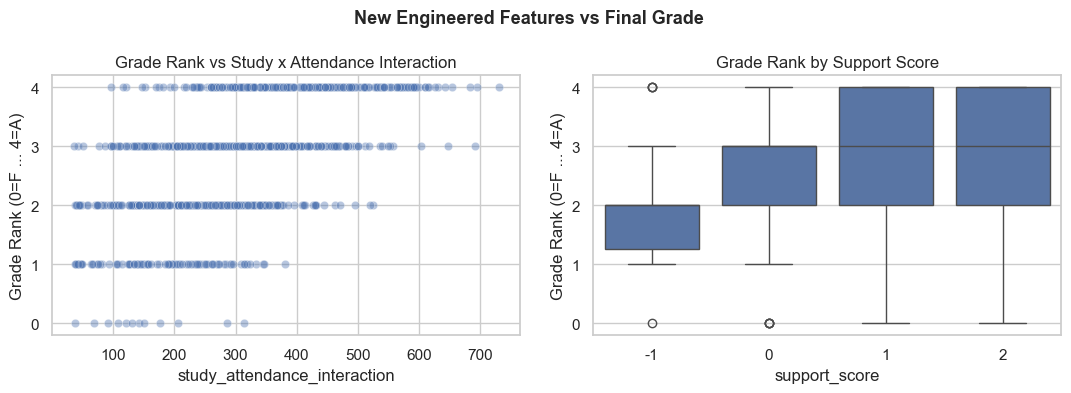

In [12]:
grade_rank_series = df_fe['final_grade'].map(grade_rank)

print("Correlation of engineered features with ordinal grade rank:")
print(df_fe[['study_attendance_interaction', 'support_score']].corrwith(grade_rank_series).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(x=df_fe['study_attendance_interaction'], y=grade_rank_series, alpha=0.4, ax=axes[0])
axes[0].set_title('Grade Rank vs Study x Attendance Interaction')
axes[0].set_ylabel('Grade Rank (0=F ... 4=A)')

sns.boxplot(x=df_fe['support_score'], y=grade_rank_series, ax=axes[1])
axes[1].set_title('Grade Rank by Support Score')
axes[1].set_ylabel('Grade Rank (0=F ... 4=A)')

plt.suptitle('New Engineered Features vs Final Grade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 5: Preprocessing

- Drop `student_id` and `final_exam_score`
- Fill missing `parental_education` with `'Unknown'` instead of dropping ~10% of rows
- Ordinal-encode `parental_education` (High School < Bachelors < Masters < PhD), with `Unknown`
  mapped to 0 since it shouldn't sit in the middle of a real ranking
- One-hot encode `gender`, `internet_access`, `extracurricular_activities`, `part_time_job` -
  no real order to these, so ordinal encoding would be wrong here (`drop_first=True` to avoid
  the dummy variable trap)
- Label-encode the target
- 80/20 stratified train/test split
- Skew correction (log1p) fit on train only, re-checked against the Step 3.4 threshold so
  nothing leaks from test
- StandardScaler on everything

`study_time_hours` and `sleep_hours` pass through as-is (no binning, see Step 4).


In [13]:
df_model = df_fe.drop(columns=['student_id', 'final_exam_score']).copy()

# Impute missing parental_education, then Ordinal Encode it
# (Unknown/NA gets least priority -> encoded as 0)
df_model['parental_education'] = df_model['parental_education'].fillna('Unknown')
education_order = ['Unknown', 'High School', 'Bachelors', 'Masters', 'PhD']
ordinal_encoder = OrdinalEncoder(categories=[education_order])
df_model['parental_education'] = ordinal_encoder.fit_transform(df_model[['parental_education']])

# Nominal (one-hot) encode the remaining binary categoricals -- no inherent order
df_model = pd.get_dummies(
    df_model,
    columns=['gender', 'internet_access', 'extracurricular_activities', 'part_time_job'],
    drop_first=True,
)

# Encode target
label_encoder = LabelEncoder()
df_model['final_grade_enc'] = label_encoder.fit_transform(df_model['final_grade'])

X = df_model.drop(columns=['final_grade', 'final_grade_enc'])
y = df_model['final_grade_enc']

print(f"Features ({len(X.columns)}): {list(X.columns)}")
print(f"parental_education ordinal mapping: {dict(enumerate(education_order))}")
print(f"Target classes (in encoded order): {list(label_encoder.classes_)}")
print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")
print(f"\nClass Distribution (encoded): {y.value_counts().to_dict()}")


Features (11): ['study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'previous_grade', 'study_attendance_interaction', 'support_score', 'gender_Male', 'internet_access_Yes', 'extracurricular_activities_Yes', 'part_time_job_Yes']
parental_education ordinal mapping: {0: 'Unknown', 1: 'High School', 2: 'Bachelors', 3: 'Masters', 4: 'PhD'}
Target classes (in encoded order): ['A', 'B', 'C', 'D', 'F']

Feature Matrix Shape : (1000, 11)
Target Shape         : (1000,)

Class Distribution (encoded): {1: 354, 0: 284, 2: 261, 3: 89, 4: 12}


In [14]:
# Stratified train/test split (preserves class ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test  = X_test.copy()

# ---- Skew correction: recompute on TRAIN only, apply the Step 3.4 threshold ----
numeric_cols_present = [c for c in numeric_cols if c in X_train.columns]
train_skew = X_train[numeric_cols_present].skew()
skew_threshold = 0.75
cols_to_fix = train_skew[abs(train_skew) > skew_threshold].index.tolist()

if cols_to_fix:
    for col in cols_to_fix:
        shift = abs(min(X_train[col].min(), X_test[col].min())) + 1 if X_train[col].min() < 0 else 0
        X_train[col] = np.log1p(X_train[col] + shift)
        X_test[col]  = np.log1p(X_test[col] + shift)
    print(f"Applied log1p to (train-fit, |skew| > {skew_threshold}): {cols_to_fix}")
else:
    print(f"No feature exceeded |skew| > {skew_threshold} on the training split — no transform applied.")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTraining set:  {X_train_scaled.shape}")
print(f"Test set:      {X_test_scaled.shape}")
print(f"\nClass split in train: {dict(pd.Series(y_train).value_counts())}")
print(f"Class split in test:  {dict(pd.Series(y_test).value_counts())}")


No feature exceeded |skew| > 0.75 on the training split — no transform applied.

Training set:  (800, 11)
Test set:      (200, 11)

Class split in train: {1: np.int64(283), 0: np.int64(227), 2: np.int64(209), 3: np.int64(71), 4: np.int64(10)}
Class split in test:  {1: np.int64(71), 0: np.int64(57), 2: np.int64(52), 3: np.int64(18), 4: np.int64(2)}


---
## Step 6: Training the Models

`evaluate_model()` runs 5-fold stratified CV on train, fits on the full training set, then
reports test accuracy, macro F1 (the classes are imbalanced, so this matters more than raw
accuracy), and macro OVR ROC-AUC. Everything lands in a `results` dict so all 9 models (and
their tuned versions later) can be compared at the end.


In [15]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None

    test_acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro') if y_proba is not None else None

    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'test_acc': test_acc,
        'macro_f1': macro_f1,
        'auc': auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"  CV Accuracy:   {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Macro F1:      {macro_f1:.4f}")
    if auc: print(f"  ROC-AUC (OVR): {auc:.4f}")
    print()

print("Helper function ready.")


Helper function ready.


### 1. Logistic Regression
Linear baseline. With 5 classes, sklearn handles it as either multinomial softmax or
one-vs-rest depending on the solver. Main things to tune: `C` and `penalty`.


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
evaluate_model('Logistic Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Logistic Regression
  CV Accuracy:   0.5550 ± 0.0165
  Test Accuracy: 0.6600
  Macro F1:      0.5134
  ROC-AUC (OVR): 0.8460



### 2. Decision Tree
A single tree of if/else splits, picked to maximize information gain at each step. Easy to
read but overfits fast if you let it grow too deep.


In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model('Decision Tree', dt, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Decision Tree
  CV Accuracy:   0.4725 ± 0.0246
  Test Accuracy: 0.5650
  Macro F1:      0.4160
  ROC-AUC (OVR): 0.7239



### 3. Random Forest
A bunch of decision trees, each trained on a bootstrapped sample with a random subset of
features per split, then majority vote. Tuning `n_estimators`, `max_depth`, `max_features`.


Model: Random Forest
  CV Accuracy:   0.5037 ± 0.0188
  Test Accuracy: 0.5650
  Macro F1:      0.4167
  ROC-AUC (OVR): 0.7793



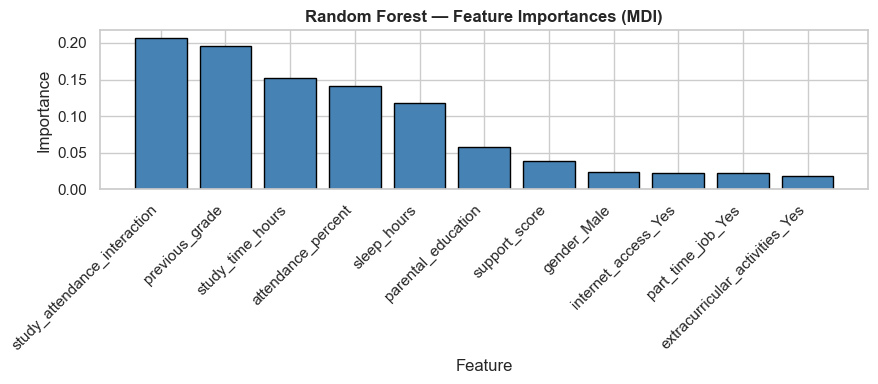

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
evaluate_model('Random Forest', rf, X_train_scaled, y_train, X_test_scaled, y_test)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(importances.index, importances.values, color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importances (MDI)', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 4. Bagging Classifier
Same bagging idea as Random Forest, but with full decision trees as the base estimator (no
feature subsampling by default).


In [19]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
evaluate_model('Bagging', bag, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Bagging
  CV Accuracy:   0.4838 ± 0.0188
  Test Accuracy: 0.5850
  Macro F1:      0.4394
  ROC-AUC (OVR): 0.8189



### 5. AdaBoost
Boosting: train a weak stump, up-weight the samples it got wrong, train the next stump on
that, repeat. Final prediction is a weighted vote. Tuning `n_estimators` and `learning_rate`.


In [20]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
evaluate_model('AdaBoost', ada, X_train_scaled, y_train, X_test_scaled, y_test)


Model: AdaBoost
  CV Accuracy:   0.4825 ± 0.0315
  Test Accuracy: 0.5200
  Macro F1:      0.3841
  ROC-AUC (OVR): 0.7170



### 6. Gradient Boosting
Also boosting, but each new tree fits the residual error instead of reweighting samples.
Tuning `n_estimators`, `learning_rate`, `max_depth`.


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
evaluate_model('Gradient Boosting', gbc, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Gradient Boosting
  CV Accuracy:   0.4912 ± 0.0359
  Test Accuracy: 0.5900
  Macro F1:      0.4625
  ROC-AUC (OVR): 0.8087



### 7. SVM (RBF kernel)
Margin-based classifier, one-vs-rest for the multi-class case here. The RBF kernel projects
into a higher-dimensional space to make classes easier to separate. Tuning `C` and `gamma`.


In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
evaluate_model('SVM (RBF)', svm, X_train_scaled, y_train, X_test_scaled, y_test)


Model: SVM (RBF)
  CV Accuracy:   0.5500 ± 0.0112
  Test Accuracy: 0.6550
  Macro F1:      0.4794
  ROC-AUC (OVR): 0.8360



### 8. Voting Ensemble
Soft-voting combination of Logistic Regression + Random Forest + Gradient Boosting - averages
their predicted probabilities.


In [23]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gbc', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ],
    voting='soft'
)
evaluate_model('Voting Ensemble (soft)', voting, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Voting Ensemble (soft)
  CV Accuracy:   0.5387 ± 0.0352
  Test Accuracy: 0.6350
  Macro F1:      0.4974
  ROC-AUC (OVR): 0.8213



### 9. Stacking
Logistic Regression, Decision Tree, and SVM as base models, with a Random Forest meta-learner
trained on their out-of-fold predictions.


In [24]:
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(
    estimators=[
        ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ],
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5,
    passthrough=False
)
evaluate_model('Stacking', stacking, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Stacking
  CV Accuracy:   0.5350 ± 0.0258
  Test Accuracy: 0.5850
  Macro F1:      0.4476
  ROC-AUC (OVR): 0.8103



---
## Step 7: Comparing Models
CV accuracy, test accuracy, macro F1 (matters more than accuracy given how rare grades F and D
are), and macro ROC-AUC across all 9 models.


In [25]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV Accuracy': [results[m]['cv_mean'] for m in results],
    'CV Std': [results[m]['cv_std'] for m in results],
    'Test Accuracy': [results[m]['test_acc'] for m in results],
    'Macro F1': [results[m]['macro_f1'] for m in results],
    'ROC-AUC': [results[m]['auc'] for m in results],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

comparison_display = comparison.copy()
comparison_display['CV Accuracy']   = comparison_display['CV Accuracy'].map('{:.4f}'.format)
comparison_display['CV Std']        = comparison_display['CV Std'].map('\u00b1{:.4f}'.format)
comparison_display['Test Accuracy'] = comparison_display['Test Accuracy'].map('{:.4f}'.format)
comparison_display['Macro F1']      = comparison_display['Macro F1'].map('{:.4f}'.format)
comparison_display['ROC-AUC']       = comparison_display['ROC-AUC'].map(lambda x: f'{x:.4f}' if x else 'N/A')

print(comparison_display.to_string(index=False))


                 Model CV Accuracy  CV Std Test Accuracy Macro F1 ROC-AUC
   Logistic Regression      0.5550 ±0.0165        0.6600   0.5134  0.8460
             SVM (RBF)      0.5500 ±0.0112        0.6550   0.4794  0.8360
Voting Ensemble (soft)      0.5387 ±0.0352        0.6350   0.4974  0.8213
     Gradient Boosting      0.4912 ±0.0359        0.5900   0.4625  0.8087
               Bagging      0.4838 ±0.0188        0.5850   0.4394  0.8189
              Stacking      0.5350 ±0.0258        0.5850   0.4476  0.8103
         Decision Tree      0.4725 ±0.0246        0.5650   0.4160  0.7239
         Random Forest      0.5037 ±0.0188        0.5650   0.4167  0.7793
              AdaBoost      0.4825 ±0.0315        0.5200   0.3841  0.7170


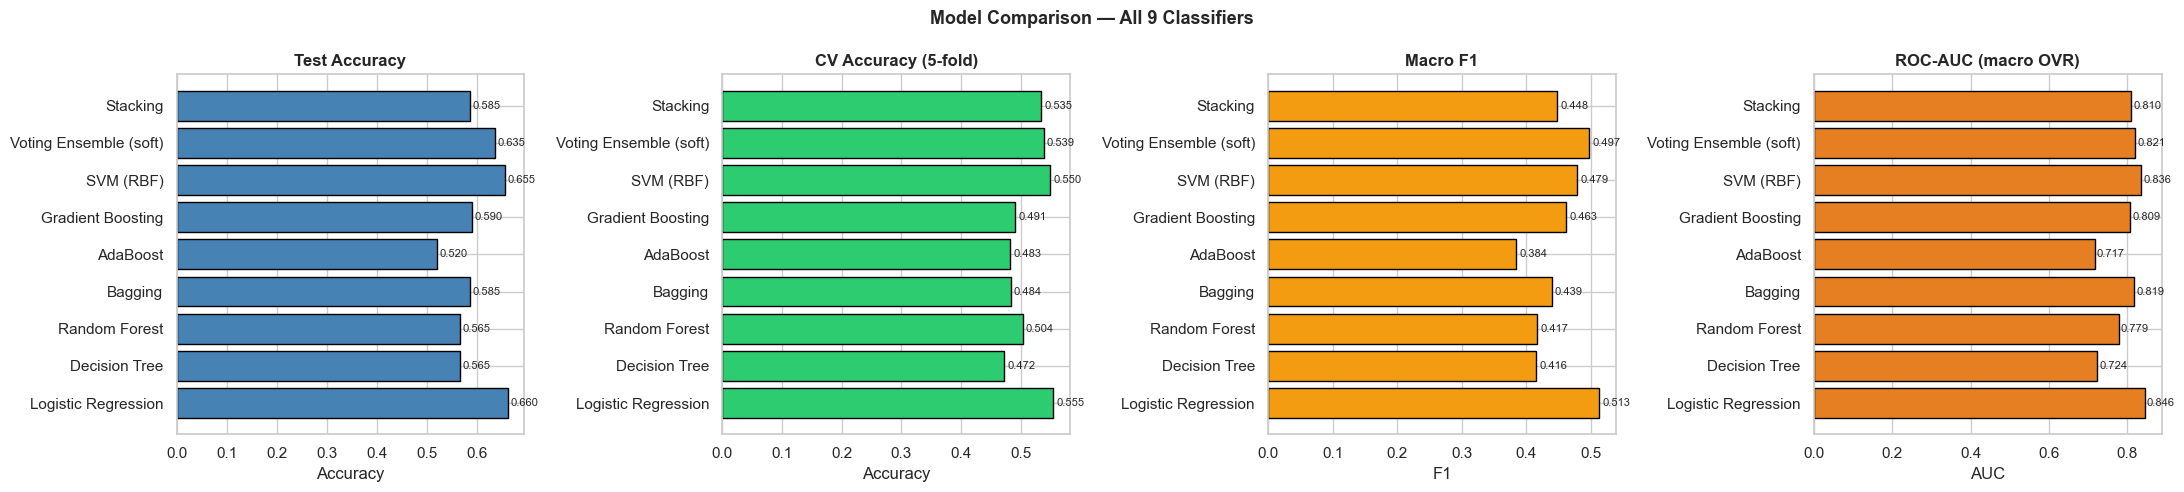

In [26]:
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] for m in model_names]
cv_means  = [results[m]['cv_mean']  for m in model_names]
macro_f1s = [results[m]['macro_f1'] for m in model_names]
aucs      = [results[m]['auc']      for m in model_names]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

bars = axes[0].barh(model_names, test_accs, color='steelblue', edgecolor='black')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xlabel('Accuracy')
for bar, val in zip(bars, test_accs):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8)

bars2 = axes[1].barh(model_names, cv_means, color='#2ecc71', edgecolor='black')
axes[1].set_title('CV Accuracy (5-fold)', fontweight='bold')
axes[1].set_xlabel('Accuracy')
for bar, val in zip(bars2, cv_means):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8)

bars3 = axes[2].barh(model_names, macro_f1s, color='#f39c12', edgecolor='black')
axes[2].set_title('Macro F1', fontweight='bold')
axes[2].set_xlabel('F1')
for bar, val in zip(bars3, macro_f1s):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8)

bars4 = axes[3].barh(model_names, aucs, color='#e67e22', edgecolor='black')
axes[3].set_title('ROC-AUC (macro OVR)', fontweight='bold')
axes[3].set_xlabel('AUC')
for bar, val in zip(bars4, aucs):
    axes[3].text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Model Comparison — All 9 Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 8: Hyperparameter Tuning

Running a separate Optuna study (TPE sampler) per model, 40 trials each, scored on 5-fold CV
accuracy. Printing every trial so I can watch progress as it runs.

Search spaces:

| Model | Parameter | Range |
|-------|-----------|-------|
| Logistic Regression | `C` | 1e-3 - 1e2 (log) |
| | `penalty` | l1, l2 |
| Decision Tree | `max_depth` | 2 - 20 |
| | `min_samples_split` | 2 - 20 |
| | `min_samples_leaf` | 1 - 10 |
| | `criterion` | gini, entropy |
| Random Forest | `n_estimators` | 50 - 500 |
| | `max_depth` | 2 - 20 |
| | `min_samples_split` | 2 - 20 |
| | `min_samples_leaf` | 1 - 10 |
| | `max_features` | sqrt, log2, None |
| Bagging | `n_estimators` | 20 - 300 |
| | `max_samples` | 0.4 - 1.0 |
| | `max_features` | 0.4 - 1.0 |
| AdaBoost | `n_estimators` | 20 - 300 |
| | `learning_rate` | 0.01 - 2.0 (log) |
| Gradient Boosting | `n_estimators` | 50 - 500 |
| | `learning_rate` | 0.01 - 0.3 (log) |
| | `max_depth` | 2 - 8 |
| | `min_samples_split` | 2 - 20 |
| | `min_samples_leaf` | 1 - 10 |
| | `subsample` | 0.5 - 1.0 |
| SVM (RBF) | `C` | 1e-2 - 1e2 (log) |
| | `gamma` | 1e-4 - 1e1 (log) |

Didn't bother tuning Voting/Stacking separately since they're just combinations of the models
above - tuning the base models already improves them indirectly.

Tuned models get run through the same `evaluate_model()` and land in the same `results` dict as
the baselines, so "pick the best model" later just looks at everything together.


In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40
tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def progress_callback(model_name):
    def _callback(study, trial):
        print(f"  [{model_name}] Trial {trial.number + 1:03d}/{N_TRIALS} "
              f"-> CV Accuracy = {trial.value:.4f} | Best so far = {study.best_value:.4f}")
    return _callback

# ---- Per-model objective functions ----
def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
    }
    model = LogisticRegression(solver='saga', max_iter=1000, random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_dt(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    model = DecisionTreeClassifier(random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = RandomForestClassifier(random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_bag(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 300),
        'max_samples': trial.suggest_float('max_samples', 0.4, 1.0),
        'max_features': trial.suggest_float('max_features', 0.4, 1.0),
    }
    model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                               random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 2.0, log=True),
    }
    model = AdaBoostClassifier(random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
    }
    model = GradientBoostingClassifier(random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True),
    }
    model = SVC(kernel='rbf', probability=True, random_state=42, **params)
    return cross_val_score(model, X_train_scaled, y_train, cv=tuning_cv, scoring='accuracy').mean()

# ---- Registry: model name -> (objective function, builder from best params) ----
tuning_registry = {
    'Logistic Regression': (
        objective_lr,
        lambda p: LogisticRegression(solver='saga', max_iter=1000, random_state=42, **p)),
    'Decision Tree': (
        objective_dt,
        lambda p: DecisionTreeClassifier(random_state=42, **p)),
    'Random Forest': (
        objective_rf,
        lambda p: RandomForestClassifier(random_state=42, **p)),
    'Bagging': (
        objective_bag,
        lambda p: BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                     random_state=42, **p)),
    'AdaBoost': (
        objective_ada,
        lambda p: AdaBoostClassifier(random_state=42, **p)),
    'Gradient Boosting': (
        objective_gbc,
        lambda p: GradientBoostingClassifier(random_state=42, **p)),
    'SVM (RBF)': (
        objective_svm,
        lambda p: SVC(kernel='rbf', probability=True, random_state=42, **p)),
}

tuning_studies = {}
tuned_results  = {}

for name, (objective_fn, builder_fn) in tuning_registry.items():
    print("=" * 60)
    print(f"Tuning: {name}  ({N_TRIALS} trials)")
    print("=" * 60)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective_fn, n_trials=N_TRIALS, callbacks=[progress_callback(name)])
    tuning_studies[name] = study

    print(f"\n  Best CV Accuracy for {name}: {study.best_value:.4f}")
    print(f"  Best Parameters: {study.best_params}\n")

    tuned_model = builder_fn(study.best_params)
    evaluate_model(f'{name} (Tuned)', tuned_model, X_train_scaled, y_train, X_test_scaled, y_test)

    tuned_results[name] = {
        'cv_best_accuracy': study.best_value,
        'best_params': study.best_params,
        'test_acc': results[f'{name} (Tuned)']['test_acc'],
        'macro_f1': results[f'{name} (Tuned)']['macro_f1'],
        'auc': results[f'{name} (Tuned)']['auc'],
    }

print("\nAll models tuned.")


Tuning: Logistic Regression  (40 trials)
  [Logistic Regression] Trial 001/40 -> CV Accuracy = 0.5388 | Best so far = 0.5388
  [Logistic Regression] Trial 002/40 -> CV Accuracy = 0.5537 | Best so far = 0.5537
  [Logistic Regression] Trial 003/40 -> CV Accuracy = 0.3538 | Best so far = 0.5537
  [Logistic Regression] Trial 004/40 -> CV Accuracy = 0.5588 | Best so far = 0.5588
  [Logistic Regression] Trial 005/40 -> CV Accuracy = 0.5563 | Best so far = 0.5588
  [Logistic Regression] Trial 006/40 -> CV Accuracy = 0.5300 | Best so far = 0.5588
  [Logistic Regression] Trial 007/40 -> CV Accuracy = 0.5550 | Best so far = 0.5588
  [Logistic Regression] Trial 008/40 -> CV Accuracy = 0.5212 | Best so far = 0.5588
  [Logistic Regression] Trial 009/40 -> CV Accuracy = 0.5563 | Best so far = 0.5588
  [Logistic Regression] Trial 010/40 -> CV Accuracy = 0.5575 | Best so far = 0.5588
  [Logistic Regression] Trial 011/40 -> CV Accuracy = 0.5575 | Best so far = 0.5588
  [Logistic Regression] Trial 012/4

Hyperparameter Tuning Summary (all tuned models):
              Model  CV Best Accuracy  Test Accuracy  Macro F1  ROC-AUC
Logistic Regression           0.55875          0.660  0.505117 0.845557
          SVM (RBF)           0.56500          0.660  0.418060 0.852206
  Gradient Boosting           0.53250          0.625  0.470099 0.820165
      Random Forest           0.55000          0.620  0.412554 0.836476
           AdaBoost           0.50625          0.605  0.433707 0.754526
            Bagging           0.52625          0.605  0.444953 0.819506
      Decision Tree           0.49250          0.535  0.388595 0.754476

Best tuned model overall: Logistic Regression
Best Parameters:  {'C': 3.4702669886504163, 'penalty': 'l2'}
CV Best Accuracy: 0.5588
Test Accuracy:    0.6600
Macro F1:         0.5051
ROC-AUC:          0.8456


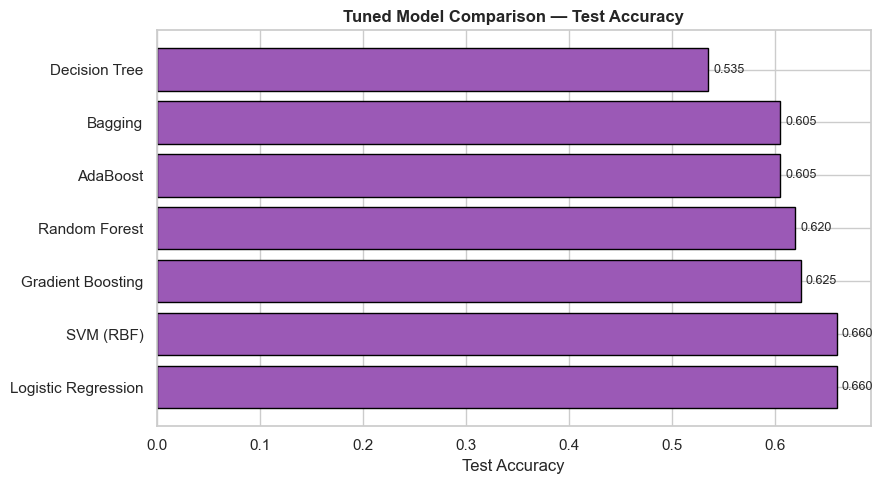


Note: 'results' now holds both baseline (Step 6) and tuned (Step 8) entries for every model, so Step 9 below automatically compares across all of them.


In [28]:
# ---- Hyperparameter Tuning Summary: all tuned models side-by-side ----
tuning_summary = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'CV Best Accuracy': [tuned_results[m]['cv_best_accuracy'] for m in tuned_results],
    'Test Accuracy':    [tuned_results[m]['test_acc'] for m in tuned_results],
    'Macro F1':         [tuned_results[m]['macro_f1'] for m in tuned_results],
    'ROC-AUC':          [tuned_results[m]['auc'] for m in tuned_results],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("Hyperparameter Tuning Summary (all tuned models):")
print(tuning_summary.to_string(index=False))

best_tuned_name = tuning_summary.iloc[0]['Model']
print(f"\nBest tuned model overall: {best_tuned_name}")
print(f"Best Parameters:  {tuned_results[best_tuned_name]['best_params']}")
print(f"CV Best Accuracy: {tuned_results[best_tuned_name]['cv_best_accuracy']:.4f}")
print(f"Test Accuracy:    {tuned_results[best_tuned_name]['test_acc']:.4f}")
print(f"Macro F1:         {tuned_results[best_tuned_name]['macro_f1']:.4f}")
print(f"ROC-AUC:          {tuned_results[best_tuned_name]['auc']:.4f}")

plt.figure(figsize=(9, 5))
bars = plt.barh(tuning_summary['Model'], tuning_summary['Test Accuracy'],
                 color='#9b59b6', edgecolor='black')
plt.xlabel('Test Accuracy')
plt.title('Tuned Model Comparison — Test Accuracy', fontweight='bold')
for bar, val in zip(bars, tuning_summary['Test Accuracy']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nNote: 'results' now holds both baseline (Step 6) and tuned (Step 8) entries for every "
      "model, so Step 9 below automatically compares across all of them.")


---
## Step 9: Final Evaluation

Pick whichever model (baseline or tuned) scored best on test accuracy, then look at:
1. Confusion matrix (5x5, one row/column per grade)
2. Classification report (precision/recall/F1 per grade)
3. Per-class ROC curves

Rows = actual grade, columns = predicted. Mistakes near the diagonal (predicting B instead of
A) are a lot less bad than mistakes far from it (predicting A instead of F).


Best model: Logistic Regression
Test Accuracy: 0.6600
Macro F1:      0.5134
ROC-AUC:       0.8460


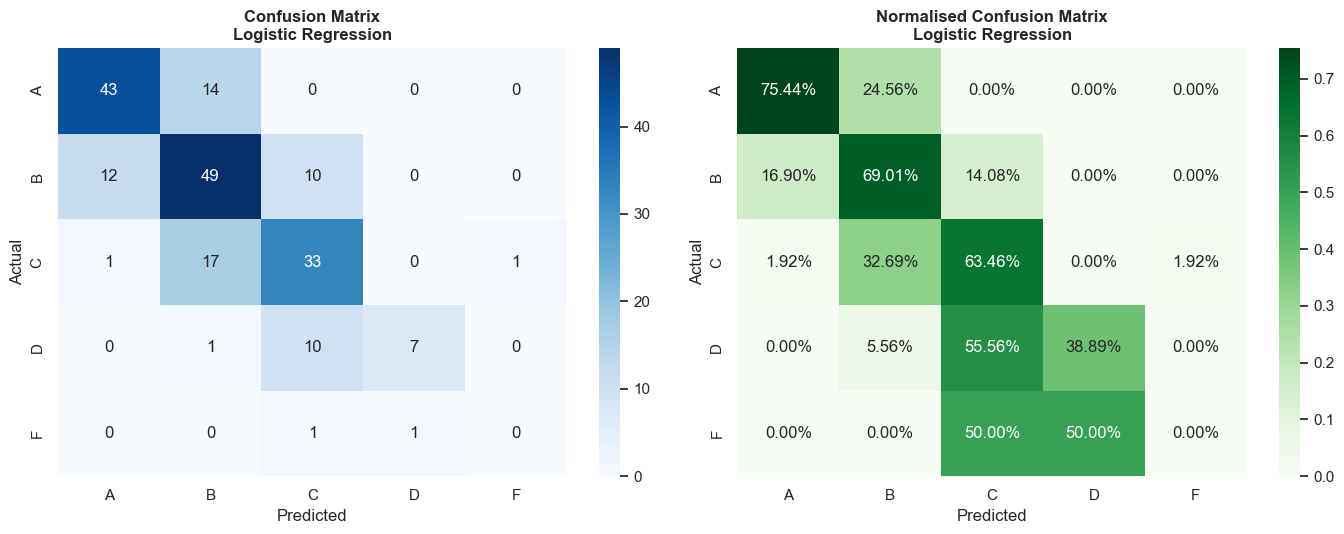

In [29]:
best_name = max(results, key=lambda m: results[m]['test_acc'])
best_result = results[best_name]
print(f"Best model: {best_name}")
print(f"Test Accuracy: {best_result['test_acc']:.4f}")
print(f"Macro F1:      {best_result['macro_f1']:.4f}")
print(f"ROC-AUC:       {best_result['auc']:.4f}")

grade_labels = list(label_encoder.classes_)

cm = confusion_matrix(y_test, best_result['y_pred'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=grade_labels, yticklabels=grade_labels)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=grade_labels, yticklabels=grade_labels)
axes[1].set_title(f'Normalised Confusion Matrix\n{best_name}', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


In [30]:
print("Classification Report:")
print(classification_report(y_test, best_result['y_pred'], target_names=grade_labels, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           A       0.77      0.75      0.76        57
           B       0.60      0.69      0.64        71
           C       0.61      0.63      0.62        52
           D       0.88      0.39      0.54        18
           F       0.00      0.00      0.00         2

    accuracy                           0.66       200
   macro avg       0.57      0.49      0.51       200
weighted avg       0.67      0.66      0.66       200



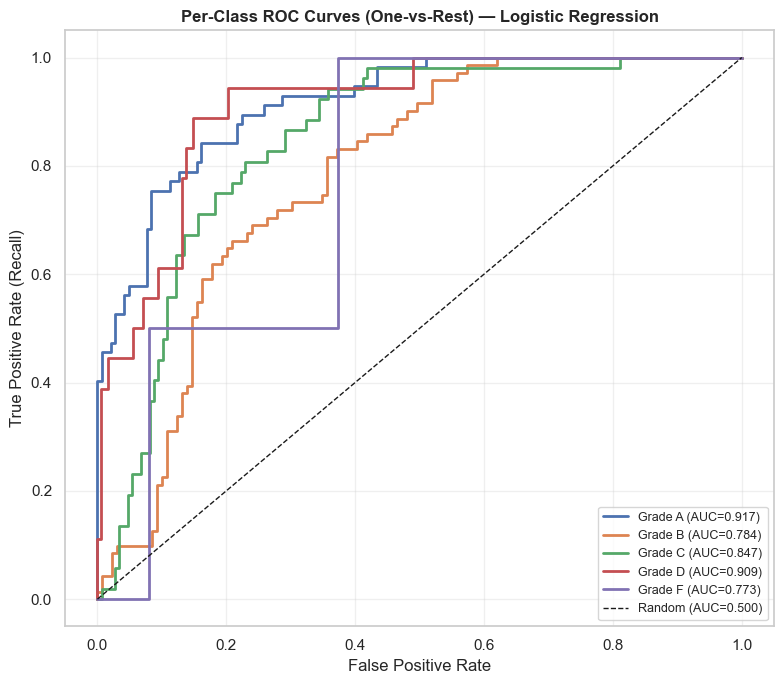

In [31]:
y_test_bin = label_binarize(y_test, classes=list(range(len(grade_labels))))

plt.figure(figsize=(8, 7))
for i, grade in enumerate(grade_labels):
    if best_result['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_result['y_proba'][:, i])
        class_auc = roc_auc_score(y_test_bin[:, i], best_result['y_proba'][:, i])
        plt.plot(fpr, tpr, linewidth=2, label=f'Grade {grade} (AUC={class_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'Per-Class ROC Curves (One-vs-Rest) — {best_name}', fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Summary

Raw data -> EDA -> a couple of engineered features -> preprocessing (encoding + scaling) -> 9
baseline models -> comparison -> per-model Optuna tuning -> final evaluation on whichever model
actually won.

Some things worth noting:
- Dropped `final_exam_score` on purpose since `final_grade` is literally derived from it -
  keeping it in would be cheating
- The target is imbalanced (grade F is ~1% of the data, D ~9%), so macro F1 and per-class ROC
  matter more than raw accuracy here
- Tuned each model separately instead of just tuning the best baseline, since the ranking can
  change after tuning

Next up if I revisit this: try SMOTE / class weights for the rare grades, maybe SHAP for
explainability, and possibly wrap the winning model in a small API.


---
## Bonus: Reusing the Tuned Logistic Regression Elsewhere

Step 8 turned up Logistic Regression as the strongest single model, so this section tries
reusing its tuned hyperparameters in a couple of other places, without touching anything in the
pipeline above.

- **Voting Ensemble** - swap the default LR component for the tuned one
- **AdaBoost** - use the tuned LR as the weak learner instead of the default decision stump
  (AdaBoost is a generic wrapper around any estimator, so this is a valid swap)
- **Gradient Boosting** and **XGBoost** - these can't take an arbitrary classifier as a base
  learner (both are tree-boosting algorithms by design, no such parameter exists in either
  API), so instead of forcing LR in there, this just adds a standalone XGBoost model for
  comparison (Gradient Boosting itself was already covered back in Step 6/8)


In [32]:
best_lr_params = tuned_results['Logistic Regression']['best_params']
print("Reusing tuned Logistic Regression params:", best_lr_params)

tuned_lr = LogisticRegression(solver='saga', max_iter=1000, random_state=42, **best_lr_params)


Reusing tuned Logistic Regression params: {'C': 3.4702669886504163, 'penalty': 'l2'}


In [33]:
voting_tuned_lr = VotingClassifier(
    estimators=[
        ('lr_tuned', tuned_lr),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gbc', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ],
    voting='soft'
)
evaluate_model('Voting Ensemble (Tuned LR)', voting_tuned_lr, X_train_scaled, y_train, X_test_scaled, y_test)


Model: Voting Ensemble (Tuned LR)
  CV Accuracy:   0.5437 ± 0.0354
  Test Accuracy: 0.6450
  Macro F1:      0.5042
  ROC-AUC (OVR): 0.8193



In [34]:
ada_tuned_lr = AdaBoostClassifier(estimator=tuned_lr, n_estimators=100, learning_rate=1.0, random_state=42)
evaluate_model('AdaBoost (Tuned LR base)', ada_tuned_lr, X_train_scaled, y_train, X_test_scaled, y_test)


Model: AdaBoost (Tuned LR base)
  CV Accuracy:   0.5263 ± 0.0133
  Test Accuracy: 0.6100
  Macro F1:      0.4543
  ROC-AUC (OVR): 0.7399



In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    random_state=42, eval_metric='mlogloss'
)
evaluate_model('XGBoost', xgb_model, X_train_scaled, y_train, X_test_scaled, y_test)


Model: XGBoost
  CV Accuracy:   0.5100 ± 0.0267
  Test Accuracy: 0.6100
  Macro F1:      0.4472
  ROC-AUC (OVR): 0.7918



In [36]:
bonus_models = ['Voting Ensemble (Tuned LR)', 'AdaBoost (Tuned LR base)', 'XGBoost']
bonus_comparison = pd.DataFrame({
    'Model': bonus_models,
    'Test Accuracy': [results[m]['test_acc'] for m in bonus_models],
    'Macro F1': [results[m]['macro_f1'] for m in bonus_models],
    'ROC-AUC': [results[m]['auc'] for m in bonus_models],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("Bonus models:")
print(bonus_comparison.to_string(index=False))

overall_best = max(results, key=lambda m: results[m]['test_acc'])
print(f"\nOverall best model across everything (main pipeline + bonus): {overall_best}")
print(f"Test Accuracy: {results[overall_best]['test_acc']:.4f}")


Bonus models:
                     Model  Test Accuracy  Macro F1  ROC-AUC
Voting Ensemble (Tuned LR)          0.645  0.504184 0.819260
  AdaBoost (Tuned LR base)          0.610  0.454261 0.739902
                   XGBoost          0.610  0.447237 0.791751

Overall best model across everything (main pipeline + bonus): Logistic Regression
Test Accuracy: 0.6600
